# Model Evaluation

## Objective

In this notebook, we will practice:

### Classification Metrics
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1 Score
- ROC Curve
- AUC

### Regression Metrics
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification Evaluation

For practice, we will use small actual and predicted values.

- `1` = Positive
- `0` = Negative

In [2]:
y_actual = np.array([
    1, 0, 1, 1, 0,
    1, 0, 0, 1, 0
])

y_pred = np.array([
    1, 0, 1, 0, 0,
    1, 1, 0, 1, 0
])

classification_results = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": y_pred
})

classification_results

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,1,0
4,0,0
5,1,1
6,0,1
7,0,0
8,1,1
9,0,0


In [3]:
cm = confusion_matrix(
    y_actual,
    y_pred
)

cm

array([[4, 1],
       [1, 4]])

In [4]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 4
False Positive: 1
False Negative: 1
True Positive : 4


In [5]:
accuracy = accuracy_score(
    y_actual,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy, 2)
)

Accuracy: 0.8


In [6]:
precision = precision_score(
    y_actual,
    y_pred
)

print(
    "Precision:",
    round(precision, 2)
)

Precision: 0.8


In [7]:
recall = recall_score(
    y_actual,
    y_pred
)

print(
    "Recall:",
    round(recall, 2)
)

Recall: 0.8


In [8]:
f1 = f1_score(
    y_actual,
    y_pred
)

print(
    "F1 Score:",
    round(f1, 2)
)

F1 Score: 0.8


In [9]:
classification_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

classification_summary.round(2)

,Metric,Score
0,Accuracy,0.8
1,Precision,0.8
2,Recall,0.8
3,F1 Score,0.8


# ROC Curve and AUC

ROC stands for Receiver Operating Characteristic.

The ROC Curve evaluates classification behavior across different probability thresholds.

AUC summarizes the area under the ROC Curve.

In [10]:
y_probability = np.array([
    0.90, 0.20, 0.80, 0.40, 0.30,
    0.75, 0.60, 0.10, 0.85, 0.25
])

probability_results = pd.DataFrame({
    "Actual": y_actual,
    "Probability": y_probability
})

probability_results

,Actual,Probability
0,1,0.90
1,0,0.20
2,1,0.80
3,1,0.40
4,0,0.30
5,1,0.75
6,0,0.60
7,0,0.10
8,1,0.85
9,0,0.25


In [11]:
fpr, tpr, thresholds = roc_curve(
    y_actual,
    y_probability
)

print("False Positive Rate:")
print(fpr)

print("\nTrue Positive Rate:")
print(tpr)

print("\nThresholds:")
print(thresholds)

False Positive Rate:
[0.  0.  0.  0.2 0.2 1. ]

True Positive Rate:
[0.  0.2 0.8 0.8 1.  1. ]

Thresholds:
[ inf 0.9  0.75 0.6  0.4  0.1 ]


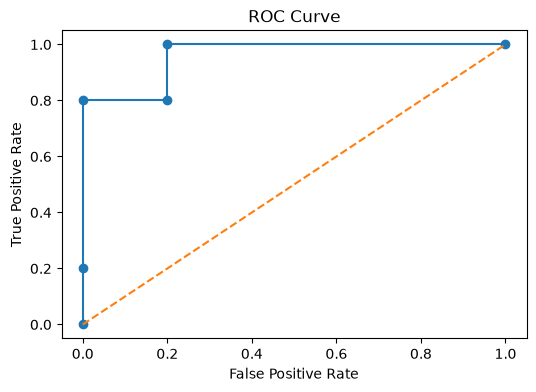

In [12]:
plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve"
)

plt.show()

In [13]:
auc = roc_auc_score(
    y_actual,
    y_probability
)

print(
    "ROC-AUC:",
    round(auc, 2)
)

ROC-AUC: 0.96


# Regression Evaluation

For Regression, we compare actual numerical values with predicted numerical values.

We will calculate:

- MAE
- MSE
- RMSE
- R² Score

In [14]:
actual_price = np.array([
    50, 60, 75, 90, 100
])

predicted_price = np.array([
    52, 57, 78, 85, 110
])

regression_results = pd.DataFrame({
    "Actual Price": actual_price,
    "Predicted Price": predicted_price
})

regression_results

,Actual Price,Predicted Price
0,50,52
1,60,57
2,75,78
3,90,85
4,100,110


In [15]:
mae = mean_absolute_error(
    actual_price,
    predicted_price
)

print(
    "MAE:",
    round(mae, 2)
)

MAE: 4.6


In [16]:
mse = mean_squared_error(
    actual_price,
    predicted_price
)

print(
    "MSE:",
    round(mse, 2)
)

MSE: 29.4


In [17]:
rmse = np.sqrt(mse)

print(
    "RMSE:",
    round(rmse, 2)
)

RMSE: 5.42


In [18]:
r2 = r2_score(
    actual_price,
    predicted_price
)

print(
    "R² Score:",
    round(r2, 2)
)

R² Score: 0.91


In [19]:
regression_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Score": [
        mae,
        mse,
        rmse,
        r2
    ]
})

regression_summary.round(2)

,Metric,Score
0,MAE,4.60
1,MSE,29.40
2,RMSE,5.42
3,R²,0.91


# Summary

## Classification Metrics

- Confusion Matrix shows TP, TN, FP, and FN.
- Accuracy measures overall correctness.
- Precision evaluates predicted Positive cases.
- Recall evaluates actual Positive cases.
- F1 Score balances Precision and Recall.
- ROC stands for Receiver Operating Characteristic.
- ROC Curve shows TPR vs FPR across thresholds.
- AUC summarizes the area under the ROC Curve.

## Regression Metrics

- MAE measures average absolute error.
- MSE squares errors and penalizes large mistakes more strongly.
- RMSE is the square root of MSE and returns error to the original target unit.
- R² measures explained target variation relative to a mean-based baseline.

## Important

No single evaluation metric is best for every Machine Learning problem.

The metric should be selected according to the problem and the real-world cost of different errors.